In [1]:
import sys
sys.path.append('..')  # import src when running from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

from src import config
from src.data_preprocessing import build_dataset, save_artifacts, load_raw_data
from src.model import build_model
from src.predict import predict_category

plt.rcParams['figure.facecolor'] = 'white'
CATEGORY_COLORS = {
    'business': '#3B6E8F', 'entertainment': '#8E4B6B', 'politics': '#6B5B95',
    'sport': '#3E7D5A', 'tech': '#A56A3A',
}


I0000 00:00:1784278157.594366     557 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784278157.597123     557 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784278176.241741     557 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784278187.163492     557 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784278187.166831     557 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Explore the raw data

In [2]:
sentences, labels = load_raw_data()
print(f'Total articles: {len(sentences)}')
print(f'Categories: {sorted(set(labels))}')
print()
print('Sample article (business):')
print(sentences[0][:400], '...')


Total articles: 2225
Categories: ['business', 'entertainment', 'politics', 'sport', 'tech']

Sample article (business):
tv future hands viewers home theatre systems  plasma high-definition tvs  digital video recorders moving living room  way people watch tv will radically different five years  time.  according expert panel gathered annual consumer electronics show las vegas discuss new technologies will impact one favourite pastimes. us leading trend  programmes content will delivered viewers via home networks  cab ...


### Class balance

How many articles per category — an unbalanced dataset would need extra care (class weights, stratified sampling, etc.).

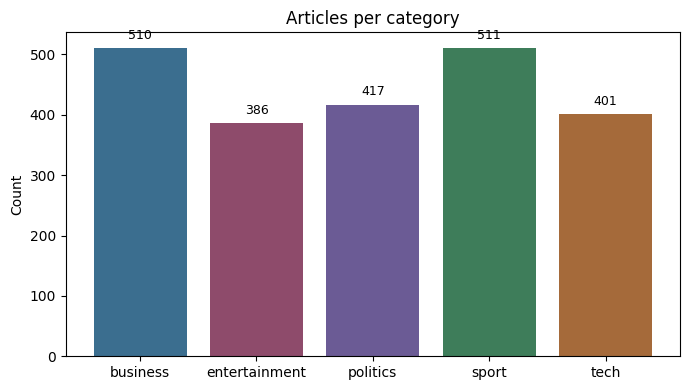

business         510
entertainment    386
politics         417
sport            511
tech             401
Name: count, dtype: int64


In [3]:
counts = pd.Series(labels).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = [CATEGORY_COLORS[c] for c in counts.index]
ax.bar(counts.index, counts.values, color=colors)
ax.set_title('Articles per category')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 15, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(counts)


### Article length distribution

This matters directly for `max_length` and for understanding the masking fix used in `src/model.py`: most articles are long, so short queries at inference time look statistically different from anything the model trained on unless padding is masked.

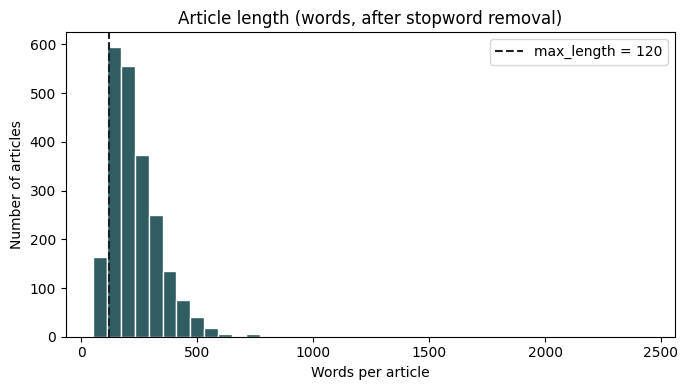

Median length: 206 words
Articles longer than max_length (120): 90.0%


In [4]:
word_counts = [len(s.split()) for s in sentences]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(word_counts, bins=40, color='#2F5D62', edgecolor='white')
ax.axvline(config.MAX_LENGTH, color='#1C1F26', linestyle='--', label=f'max_length = {config.MAX_LENGTH}')
ax.set_title('Article length (words, after stopword removal)')
ax.set_xlabel('Words per article')
ax.set_ylabel('Number of articles')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median length: {np.median(word_counts):.0f} words')
print(f'Articles longer than max_length ({config.MAX_LENGTH}): '
      f'{np.mean(np.array(word_counts) > config.MAX_LENGTH) * 100:.1f}%')


### Most frequent words per category

A quick sanity check that the categories are actually separable by vocabulary — no modeling yet, just counting.

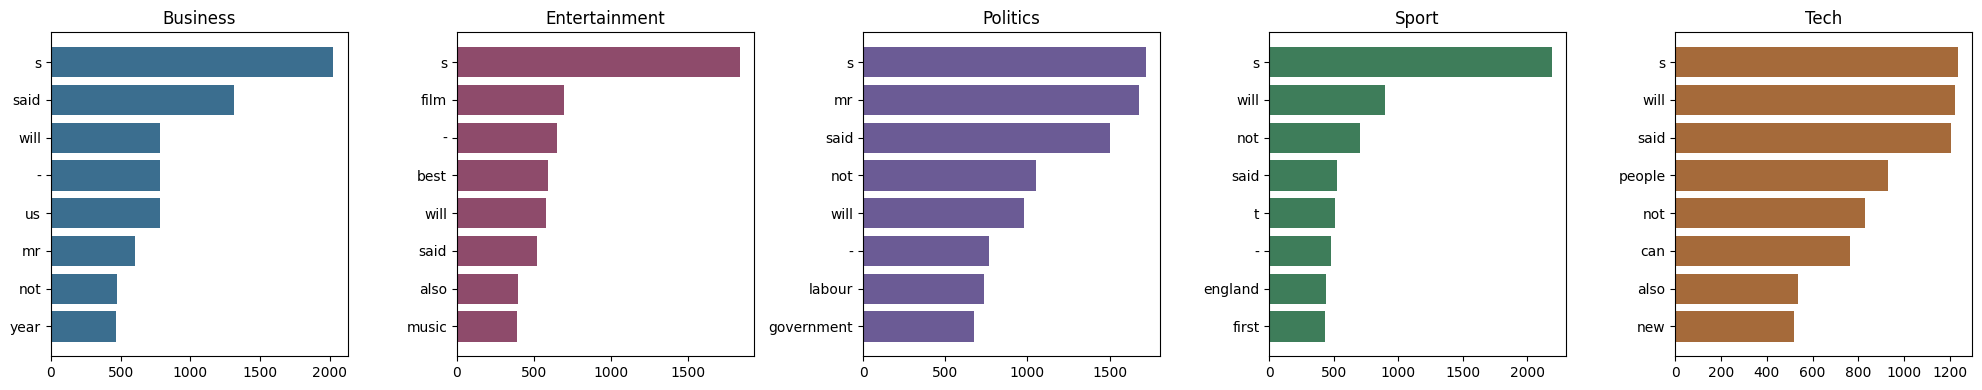

In [5]:
from collections import Counter

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
for ax, category in zip(axes, sorted(set(labels))):
    cat_words = ' '.join(s for s, l in zip(sentences, labels) if l == category).split()
    top = Counter(cat_words).most_common(8)
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color=CATEGORY_COLORS[category])
    ax.set_title(category.capitalize())
plt.tight_layout()
plt.show()


## 2. Build the preprocessed dataset

Tokenizes the text, pads/truncates sequences to `max_length`, splits train/validation (80/20), and encodes labels with a plain 0-indexed `LabelEncoder` — mapping each category to an index in `{0, ..., 4}` that lines up exactly with the model's 5 output units.

In [6]:
dataset = build_dataset()

print('Label mapping:', dataset.label_encoder.word_index)
print('Train shape:', dataset.train_padded.shape)
print('Validation shape:', dataset.validation_padded.shape)
print('Vocabulary size in use:', min(config.VOCAB_SIZE, len(dataset.tokenizer.word_index) + 1))


Label mapping: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
Train shape: (1780, 120)
Validation shape: (445, 120)
Vocabulary size in use: 1000


A quick look at what the model actually sees — raw text turned into a fixed-length sequence of integer token IDs (`1` is `<OOV>`, out-of-vocabulary).

In [7]:
example_idx = 0
print('Original (cleaned):', sentences[example_idx][:150], '...')
print()
print('Tokenized + padded:', dataset.train_padded[example_idx][:25], '...')


Original (cleaned): tv future hands viewers home theatre systems  plasma high-definition tvs  digital video recorders moving living room  way people watch tv will radical ...

Tokenized + padded: [ 99 170   1   1  55 993 771   1  97   1   1 139 186   1   1   1   1  48
   9 907  99   4   1 347  93] ...


## 3. Build the model

In [8]:
model = build_model(num_classes=dataset.label_encoder.num_classes)
model.summary()


E0000 00:00:1784278193.191586     557 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train

In [9]:
history = model.fit(
    dataset.train_padded,
    dataset.train_labels,
    epochs=config.NUM_EPOCHS,
    validation_data=(dataset.validation_padded, dataset.validation_labels),
    verbose=2,
)


Epoch 1/30


56/56 - 2s - 30ms/step - accuracy: 0.2522 - loss: 1.5931 - val_accuracy: 0.2921 - val_loss: 1.5662


Epoch 2/30


56/56 - 0s - 6ms/step - accuracy: 0.4607 - loss: 1.5231 - val_accuracy: 0.4382 - val_loss: 1.4684


Epoch 3/30


...

56/56 - 0s - 5ms/step - accuracy: 0.9994 - loss: 0.0288 - val_accuracy: 0.9551 - val_loss: 0.1799


Epoch 29/30


56/56 - 0s - 5ms/step - accuracy: 0.9994 - loss: 0.0263 - val_accuracy: 0.9528 - val_loss: 0.1835


Epoch 30/30


56/56 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0241 - val_accuracy: 0.9528 - val_loss: 0.1957


### Training curves

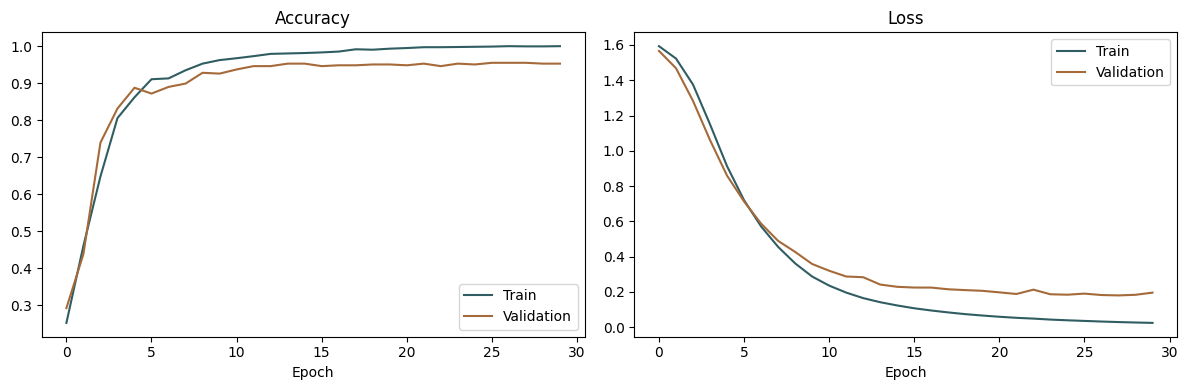

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], color='#2F5D62', label='Train')
axes[0].plot(history.history['val_accuracy'], color='#A56A3A', label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], color='#2F5D62', label='Train')
axes[1].plot(history.history['val_loss'], color='#A56A3A', label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{config.ASSETS_DIR}/accuracy_loss_combined.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Evaluate properly

Accuracy alone can hide category-specific weaknesses. A confusion matrix and per-class precision/recall/F1 show exactly where the model struggles.

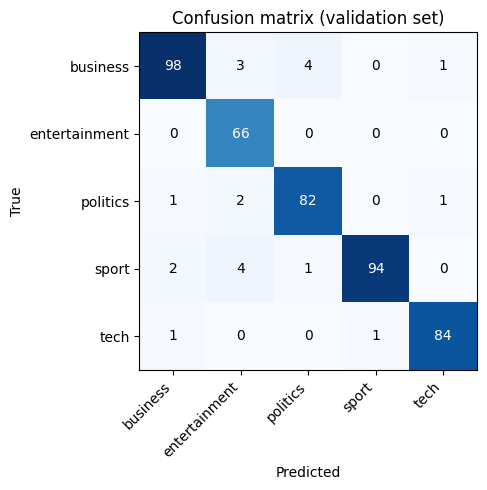

In [11]:
val_probs = model.predict(dataset.validation_padded, verbose=0)
val_preds = np.argmax(val_probs, axis=1)
class_names = [dataset.label_encoder.index_word[i] for i in range(dataset.label_encoder.num_classes)]

cm = confusion_matrix(dataset.validation_labels, val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix (validation set)')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.savefig(f'{config.ASSETS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
print(classification_report(dataset.validation_labels, val_preds, target_names=class_names))


               precision    recall  f1-score   support

     business       0.96      0.92      0.94       106
entertainment       0.88      1.00      0.94        66
     politics       0.94      0.95      0.95        86
        sport       0.99      0.93      0.96       101
         tech       0.98      0.98      0.98        86

     accuracy                           0.95       445
    macro avg       0.95      0.96      0.95       445
 weighted avg       0.95      0.95      0.95       445



## 6. Save the model & tokenizers

These are the exact artifacts the Streamlit app (`app.py`) loads at runtime.

In [13]:
model.save(config.MODEL_PATH)
save_artifacts(dataset.tokenizer, dataset.label_encoder)
print('Saved to', config.MODEL_PATH)


Saved to /home/claude/bbc-news-classifier/models/bbc_news_model.keras


## 7. Try it on fresh text

One example per category, not seen during training.

In [14]:
samples = [
    ('sport', 'Manchester United won the football match yesterday after a dramatic late goal in stoppage time.'),
    ('business', 'The stock market rallied today as investors reacted positively to the company earnings report.'),
    ('entertainment', 'The actress won the award for best performance at the film festival ceremony last night.'),
    ('politics', "The prime minister addressed parliament about the government's new healthcare policy."),
    ('tech', 'Google announced a new artificial intelligence model that outperforms its competitors in benchmark tests.'),
]

for true_label, text in samples:
    pred_label, confidence, _ = predict_category(text, model, dataset.tokenizer, dataset.label_encoder)
    marker = 'correct' if pred_label == true_label else 'WRONG'
    print(f'[{marker:7s}] true={true_label:15s} pred={pred_label:15s} ({confidence*100:5.1f}%)  {text[:55]}')


[correct] true=sport           pred=sport           (100.0%)  Manchester United won the football match yesterday afte
[correct] true=business        pred=business        (100.0%)  The stock market rallied today as investors reacted pos


[correct] true=entertainment   pred=entertainment   (100.0%)  The actress won the award for best performance at the f


[correct] true=politics        pred=politics        ( 99.6%)  The prime minister addressed parliament about the gover


[WRONG  ] true=tech            pred=entertainment   ( 51.9%)  Google announced a new artificial intelligence model th


## Next steps

- Try a larger `vocab_size` or pre-trained embeddings (GloVe) to see if accuracy improves further.
- Add a 6th "other" category and a rejection threshold for out-of-domain text.
- Fine-tune on shorter text (captions, headlines) if the model needs to run on non-article-length input.
